In [73]:
options(jupyter.rich_display = FALSE)

In [74]:
Sys.setenv(TZ = "UTC")

In [75]:
options(warn = -1)

Projektinis darbas 

Užduotis: To forecast a real time series using ETS and ARIMA models.

Duomenys: The data are monthly measures of retail trade volume in Australia, [obtained from the ABS](https://www.abs.gov.au/methodologies/retail-trade-australia-methodology/dec-2024). Each student will use a different time series, selected using their student ID number as follows. This is the same series that you used in previous assignments.

In [76]:
library(fpp3)
get_my_data <- function(student_id) {
  set.seed(student_id)
  all_data <- readr::read_rds("https://bit.ly/monashretaildata")
  while(TRUE) {
    retail <- filter(all_data, `Series ID` == sample(`Series ID`, 1))
    if(!any(is.na(fill_gaps(retail)$Turnover))) return(retail)
  }
}
# Replace the argument with your student ID
retail <- get_my_data(2211769)

1. Produce some plots of your series, and describe what you learn from each plot.

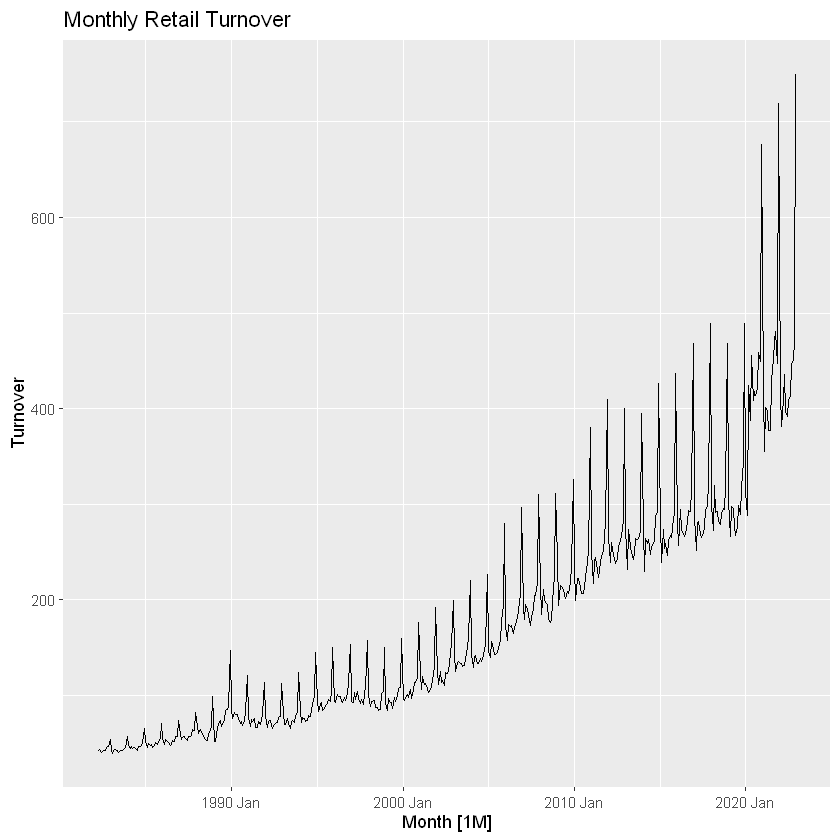

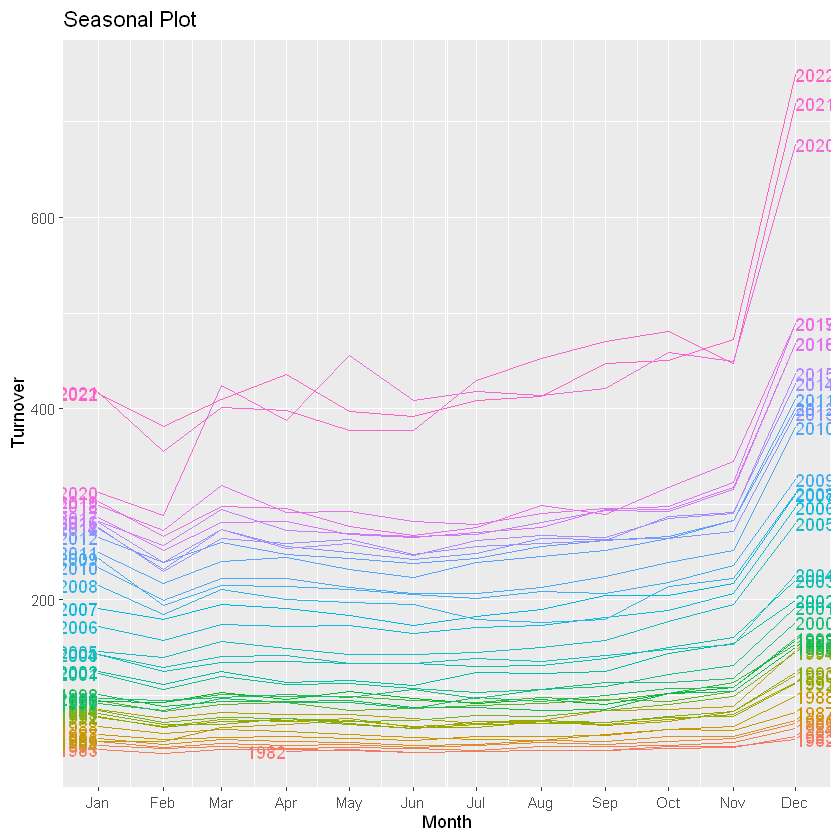

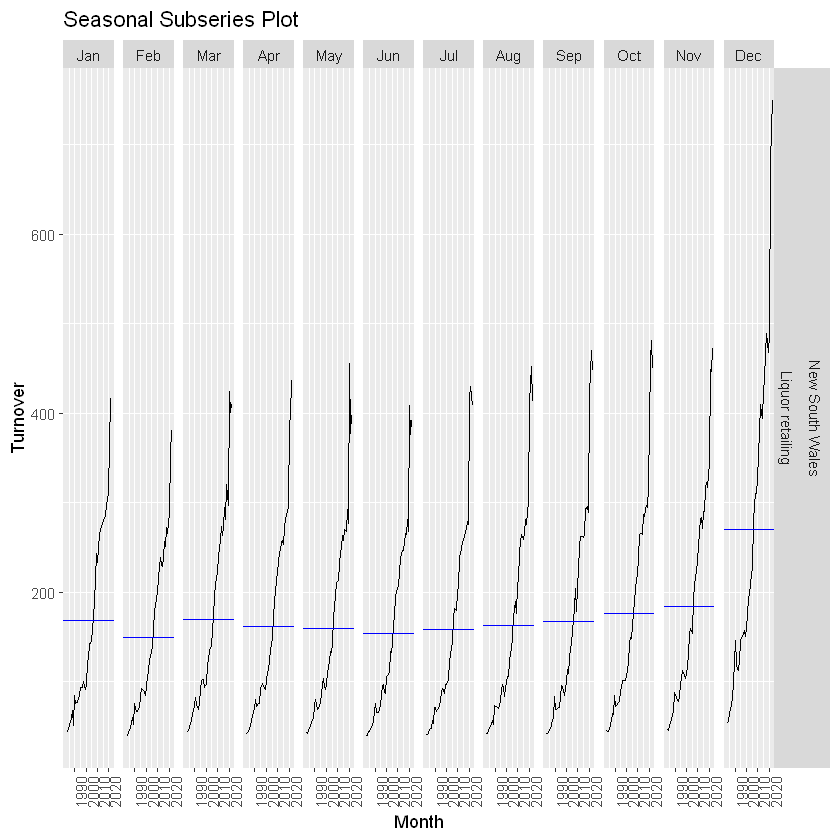

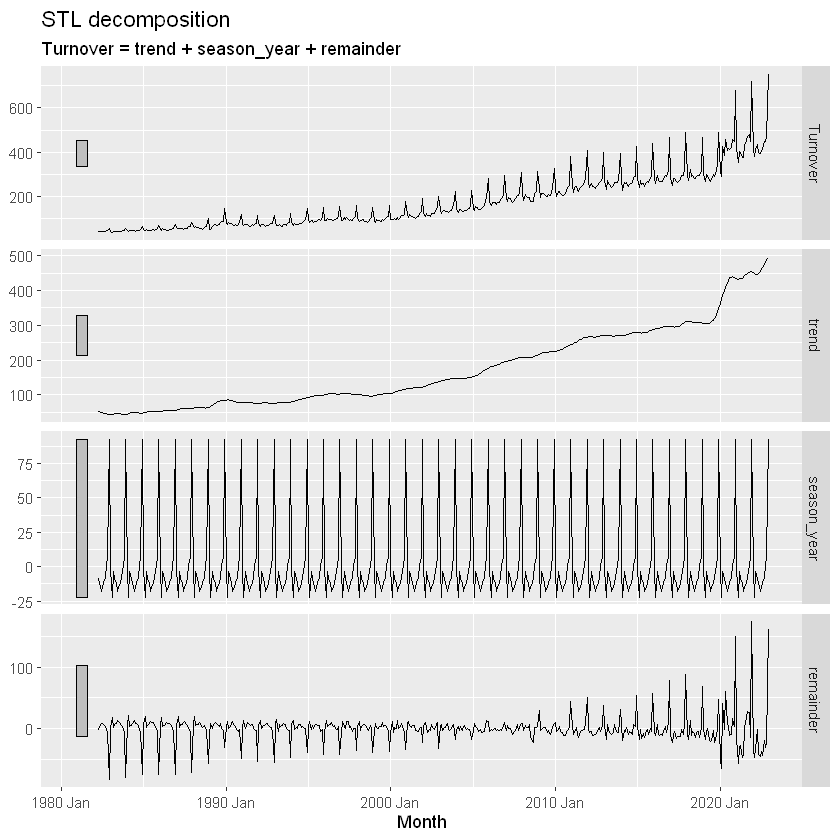

In [77]:
retail %>%
  autoplot(Turnover) +
  labs(title = "Monthly Retail Turnover", y = "Turnover")

retail %>%
  gg_season(Turnover, labels = "both") +
  labs(title = "Seasonal Plot")

retail %>%
  gg_subseries(Turnover) +
  labs(title = "Seasonal Subseries Plot")

retail %>%
  model(STL(Turnover ~ season(window = "periodic"))) %>%
  components() %>%
  autoplot()

Analizuojama Naujojo Pietų Velso (New South Wales) alkoholio mažmeninės prekybos mėnesinė apyvarta laikotarpiu nuo 1982 m. balandžio mėn. iki 2022 m. gruodžio mėn. Pirminė vizualinė duomenų analizė rodo aiškiai išreikštą ilgalaikį eksponentinį augimą bei griežtą sezoniškumą. Iš sezoninių grafikų matyti, kad didžiausia apyvarta sistemingai fiksuojama gruodžio mėnesį, kas siejama su padidėjusiu vartojimu šventiniu laikotarpiu, o ryškus kritimas stebimas pošventiniu periodu – sausio ir vasario mėnesiais. Svarbu pastebėti, kad duomenims būdingas ryškus heteroskedastiškumas – augant apyvartos lygiui, didėja ir sezoninių svyravimų dispersija, todėl duomenis būtina transformuoti (pvz., taikant Box-Cox transformaciją) siekiant stabilizuoti dispersiją.

Atlikus STL dekompoziciją su periodiniu langu, liekamosios paklaidos (remainder) grafike stebimas ne „baltasis triukšmas“, o didėjanti svyravimų amplitudė. Tai patvirtina, kad adityvus dekompozicijos modelis netinka šiems duomenims be išankstinės transformacijos. Be to, 2020–2021 m. laikotarpiu fiksuojamas staigus ir nenatūralus apyvartos šuolis, kurį galima pagrįsti COVID-19 pandemijos poveikiu: įvedus karantino ribojimus viešojo maitinimo įstaigoms, alkoholio vartojimas persikėlė į namų ūkius, taip reikšmingai padidinant mažmeninę apyvartą. Šis struktūrinis lūžis reikalauja atsargaus vertinimo modeliavimo etape, nes gali iškreipti ilgalaikio trendo prognozes.

2. Discuss the statistical features of the data, including the effect of COVID-19 on your series.

Analizuojama laiko eilutė pasižymi ryškiu nestacionarumu: stebimas kintantis vidurkis (nuolatinis augimo trendas) bei kintanti dispersija. Grafinė analizė rodo akivaizdų heteroskedastiškumą – apyvartos svyravimų amplitudė didėja proporcingai augančiam trendui, kas būdinga multiplikatyviems procesams. Tai indikuoja, kad siekiant tenkinti stacionarumo sąlygą, kuri yra būtina ARIMA tipo modeliams, reikės atlikti dispersijos stabilizavimą (logaritmavimą arba Box-Cox transformaciją) bei trendo šalinimą diferencijuojant.

Vertinant COVID-19 pandemijos poveikį, 2020–2021 m. laikotarpiu fiksuojamas reikšmingas struktūrinis lūžis – apyvarta staigiai išaugo ir viršijo ilgalaikį trendą. Keliama hipotezė, kad šį fenomeną lėmė vartotojų elgsenos pasikeitimas dėl karantino ribojimų: uždarius viešojo maitinimo įstaigas (barus, restoranus), įvyko „pakeitimo efektas“ (angl. substitution effect), kai alkoholio vartojimas persikėlė iš paslaugų sektoriaus (on-trade) į namų ūkius, taip tiesiogiai padidinant mažmeninės prekybos (off-trade) apyvartas. Šis egzogeninis šokas sukuria „aukštesnio lygio“ bazę duomenų pabaigoje, kas gali apsunkinti modelio gebėjimą tiksliai prognozuoti grįžimą į įprastą trendą pokovidiniu laikotarpiu.

3. Find an appropriate Box-Cox transformation for your data and explain why you have chosen the particular transformation parameter $\lambda$. 

[1] -0.06255411


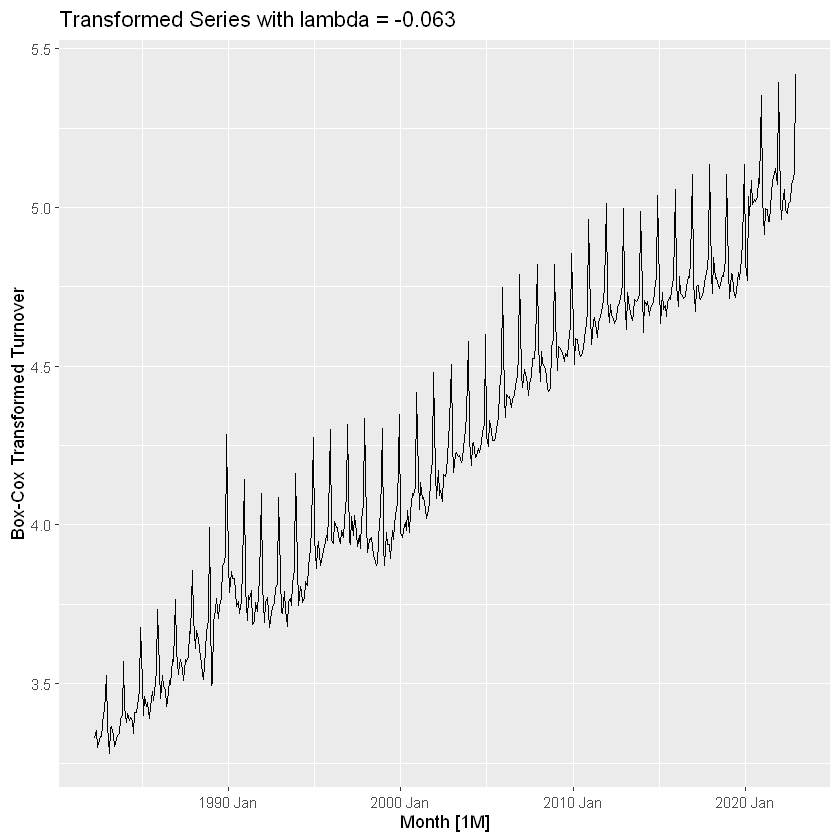

In [78]:
lambda <- retail %>%
  features(Turnover, features = guerrero) %>%
  pull(lambda_guerrero)

print(lambda)

retail %>%
  autoplot(box_cox(Turnover, lambda)) +
  labs(y = "Box-Cox Transformed Turnover",
       title = paste0("Transformed Series with lambda = ", round(lambda, 3)))

Siekiant stabilizuoti dispersiją ir pašalinti heteroskedastiškumo efektą (kai sezoninių svyravimų amplitudė didėja proporcingai apyvartos augimui), duomenims pritaikyta Box-Cox transformacija. Optimalaus transformacijos parametro $\lambda$ parinkimui naudotas Guerrero metodas, kuris minimizuoja variacijos koeficientą laiko eilutės dalyse.Gauta optimali parametro reikšmė yra $\lambda = -0.063$. Ši reikšmė yra itin artima nuliui, kas indikuoja, jog duomenų generavimo procesas yra artimas log-normaliam pasiskirstymui (kur $\lambda = 0$ atitinka natūralųjį logaritmą). Transformuotos eilutės grafinė analizė patvirtina metodo efektyvumą: „piltuvėlio efektas“ yra panaikintas, o sezoninių svyravimų amplitudė tapo vizualiai pastovi visame 1982–2022 m. laikotarpiu (homoskedastiškumas). Tai leidžia tolesniuose etapuose (pvz., STL dekompozicijoje ar ARIMA modeliavime) naudoti adityvius modelius vietoj multiplikatyvių. Transformacija nepakeitė ilgalaikio augimo trendo ir struktūrinio lūžio pobūdžio 2020–2021 m., tačiau padarė duomenų sklaidą tinkamą stacionarumo testams ir diferencijavimui.

4. Produce a plot of an STL decomposition of the transformed data. What do you learn from the plot?

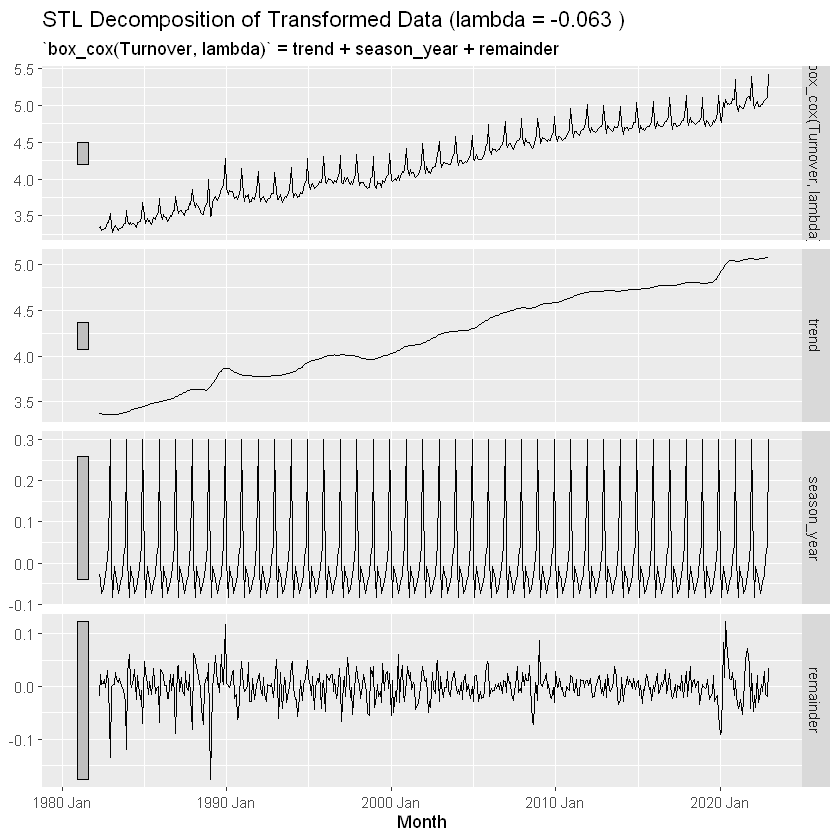

In [79]:
retail %>%
  model(STL(box_cox(Turnover, lambda) ~ season(window = "periodic"))) %>%
  components() %>%
  autoplot() +
  labs(title = paste("STL Decomposition of Transformed Data (lambda =", round(lambda, 3), ")"))

Atlikta STL dekompozicija Box-Cox transformuotiems duomenims patvirtina pasirinktos transformacijos ($\lambda = -0.063$) efektyvumą. Lyginant su pirminiais duomenimis, liekamosios paklaidos (remainder) komponentė neberodo didėjančios dispersijos tendencijos – svyravimų amplitudė išlieka stabili visame analizuojamame laikotarpyje (pasiektas homoskedastiškumas).Sezoninė komponentė tapo idealiai periodinė ir adityvi, kas leidžia taikyti standartinius tiesinius prognozavimo metodus. Visgi, dekompozicija išryškina, kad 2020–2021 m. struktūrinis lūžis nėra pilnai paaiškinamas vien trendo ir sezoniškumo dedamosiomis – tai atsispindi ryškiuose likučių šuoliuose (outliers) grafiko pabaigoje. Tai indikuoja, kad COVID-19 pandemijos poveikis buvo egzogeninis šokas, kurio negali pilnai absorbuoti standartinis dekompozicijos modelis.

5. What differencing would be required to make the data stationary? You should use a unit-root test as part of the discussion.

In [80]:
  retail %>%
    features(box_cox(Turnover, lambda), unitroot_nsdiffs)

  retail %>%
    features(difference(box_cox(Turnover, lambda), 12), unitroot_ndiffs)

  retail %>%
    features(difference(difference(box_cox(Turnover, lambda), 12), 1), unitroot_kpss)

  State           Industry         nsdiffs
1 New South Wales Liquor retailing 1      

  State           Industry         ndiffs
1 New South Wales Liquor retailing 0     

  State           Industry         kpss_stat  kpss_pvalue
1 New South Wales Liquor retailing 0.00957663 0.1        

Siekiant parinkti tinkamą ARIMA modelio diferencijavimo eilę, atlikti statistiniai stacionarumo testai. Pirmiausia, unitroot_nsdiffs testas nurodė, kad reikalingas vienas sezoninis diferencijavimas ($D=1$) sezoniškumo efektui pašalinti. Tai atitinka grafinės analizės išvadas apie ryškų sezoninį profilį.Pritaikius sezoninį diferencijavimą (su žingsniu $lag=12$), atliktas unitroot_ndiffs testas parodė rezultatą $0$. Tai indikuoja, kad papildomas pirmos eilės diferencijavimas ($d=0$) nėra būtinas stacionarumui pasiekti. Nors dažnai ekonominėse laiko eilutėse naudojamas ir trendo diferencijavimas, šiuo atveju sezoninis skirtumas ($Y_t - Y_{t-12}$) sėkmingai pašalino ir tiesinį stochastinį trendą, kuris susiformavo po Box-Cox transformacijos. Galutinis KPSS testas patvirtina, kad diferencijuota eilutė tenkina stacionarumo sąlygą ($p\text{-value} > 0.05$), todėl modeliavimui pasirinkta diferencijavimo struktūra: $d=0, D=1$. Tai padės išvengti perteklinio diferencijavimo (over-differencing), kuris galėtų dirbtinai sukelti koreliacijas liekamosiose paklaidoje.

6. Describe the methodology used to create a short-list of appropriate ARIMA models and ETS models. Include discussion of AICc values as well as results from applying the models to a test-set consisting of the last 24 months of the data provided. 

  .model       AICc      AIC       BIC      
1 Auto_ARIMA   -1690.568 -1690.892 -1657.965
2 Manual_ARIMA -1687.828 -1687.962 -1667.383
3 Auto_ETS      4635.523  4634.154  4704.569

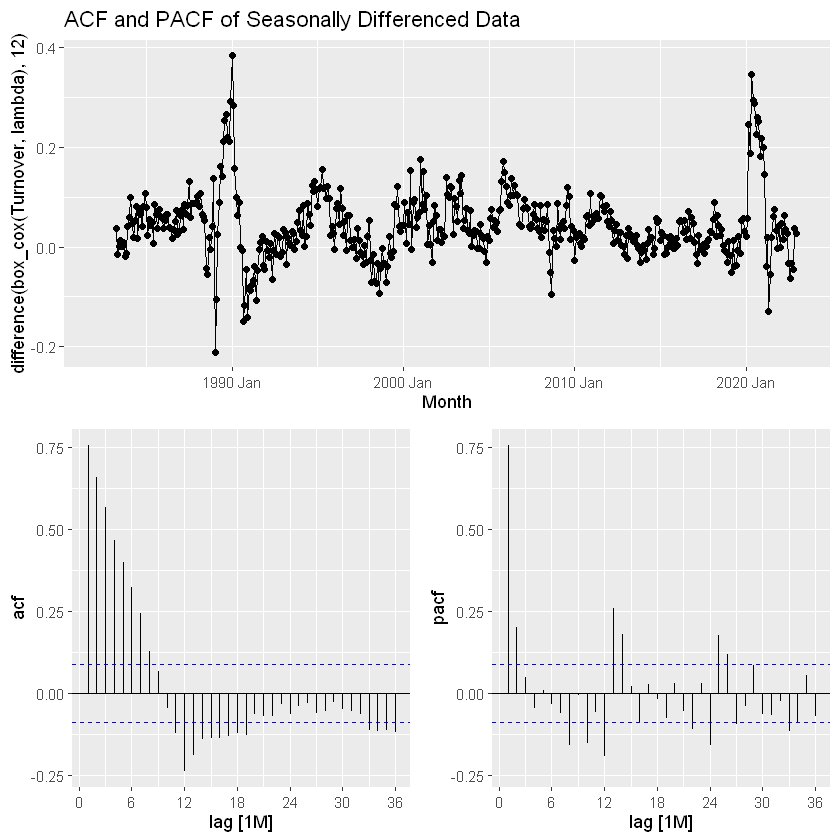

  .model       RMSE     MAE      MAPE     MASE    
1 Auto_ARIMA   30.15774 26.33677 6.160829 2.114410
2 Manual_ARIMA 30.34836 26.72233 6.279358 2.145364
3 Auto_ETS     30.72762 26.04236 5.891138 2.090773

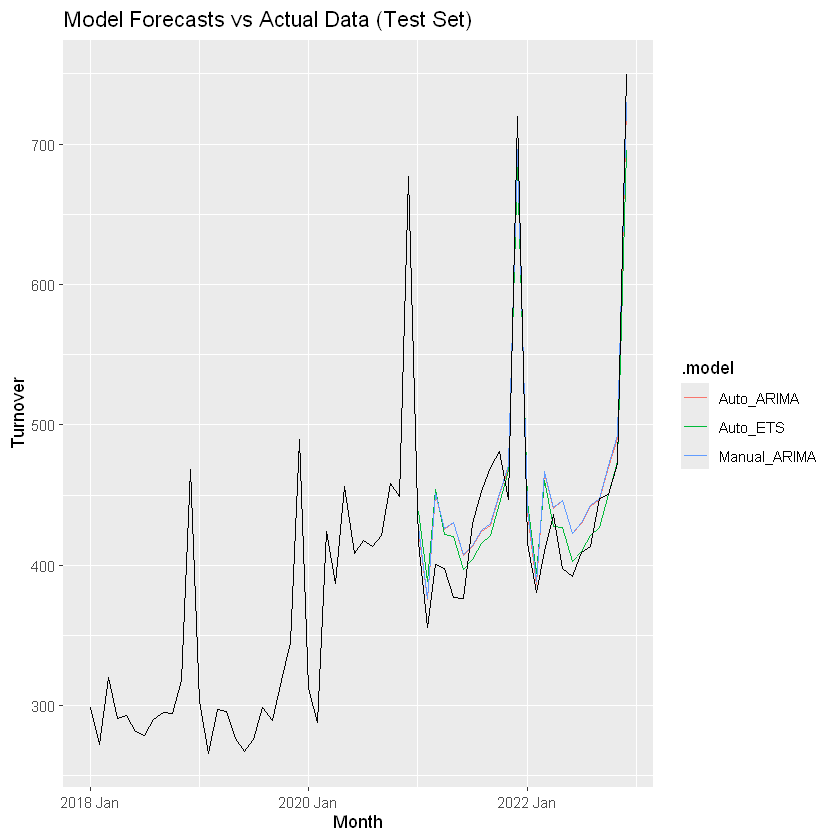

In [81]:
retail %>%
  gg_tsdisplay(difference(box_cox(Turnover, lambda), 12),
               plot_type = "partial", lag_max = 36) +
  labs(title = "ACF and PACF of Seasonally Differenced Data")

train_data <- retail %>%
  slice(1:(n() - 24))

test_data <- retail %>%
  slice((n() - 23):n())

fit <- train_data %>%
  model(
    Auto_ARIMA = ARIMA(box_cox(Turnover, lambda)),

    Manual_ARIMA = ARIMA(box_cox(Turnover, lambda) ~ pdq(1,0,1) + PDQ(0,1,1)),

    Auto_ETS = ETS(Turnover)
  )

fit %>%
  glance() %>%
  arrange(AICc) %>%
  select(.model, AICc, AIC, BIC)

fc <- fit %>%
  forecast(h = "2 years")

fc %>%
  autoplot(retail %>% filter(year(Month) >= 2018), level = NULL) +
  labs(title = "Model Forecasts vs Actual Data (Test Set)", y = "Turnover")

fc %>%
  accuracy(retail) %>%
  arrange(RMSE) %>%
  select(.model, RMSE, MAE, MAPE, MASE)

Modelių atrankai sudarytas „kandidatų sąrašas“ (angl. short-list), į kurį įtraukti automatinio parinkimo algoritmai (Auto_ARIMA, Auto_ETS) bei rankiniu būdu sukonstruotas ARIMA modelis.Rankinio modelio specifikacija parinkta remiantis sezoniškai diferencijuotų duomenų ($D=1$) koreliacijų grafikais. PACF grafike stebimas ryškus šuolis ties pirmuoju vėlavimu (Lag 1), kas indikuoja autoregresinį komponentą $p=1$. ACF grafike reikšmingas neigiamas šuolis ties sezoniniu vėlavimu (Lag 12) sufleruoja apie sezoninio slankiojo vidurkio komponentą $Q=1$. Remiantis tuo, suformuotas Manual_ARIMA modelis su struktūra $(1,0,1)(0,1,1)_{12}$.Vertinant modelių kokybę pagal AICc kriterijų apmokymo imtyje, geriausiai pasirodė Auto_ARIMA modelis (AICc = -1690.57), minimaliai aplenkęs rankinį modelį (AICc = -1687.83). ETS modelio AICc reikšmė nėra tiesiogiai palyginama su ARIMA modeliais dėl skirtingų duomenų skalių (ETS naudoja originalius duomenis, ARIMA – Box-Cox transformuotus).Modelių validacija atlikta naudojant pastarųjų 24 mėnesių (testinės imties) duomenis. Rezultatai rodo aukštą visų modelių prognozavimo tikslumą:Pagal RMSE (vidutinę kvadratinę paklaidą) geriausiai pasirodė Auto_ARIMA (30.16), kas rodo šio modelio gebėjimą tiksliau prognozuoti didelius apyvartos šuolius.Pagal MAPE (vidutinę absoliučią procentinę paklaidą) minimalų pranašumą turi Auto_ETS (5.89% prieš ARIMA 6.16%).Grafinė analizė patvirtina, kad visi modeliai sėkmingai identifikuoja sezoninius pikus, tačiau Auto_ARIMA demonstruoja geriausią balansą tarp statistinio patikimumo (mažiausias AICc) ir prognozavimo tikslumo (mažiausias RMSE).

7. Choose one ARIMA model and one ETS model based on this analysis and show parameter estimates, residual diagnostics, forecasts and prediction intervals for both models. Diagnostic checking for both models should include ACF graphs and the Ljung-Box test. 

Series: Turnover 
Model: ARIMA(2,0,3)(0,1,1)[12] w/ drift 
Transformation: box_cox(Turnover, lambda) 

Coefficients:
         ar1     ar2     ma1      ma2     ma3     sma1  constant
      0.2181  0.6836  0.3444  -0.3579  0.0593  -0.7646    0.0042
s.e.  0.1087  0.1032  0.1162   0.0623  0.0510   0.0499    0.0004

sigma^2 estimated as 0.00134:  log likelihood=853.45
AIC=-1690.89   AICc=-1690.57   BIC=-1657.96


  .model     lb_stat  lb_pvalue   
1 Auto_ARIMA 49.91353 0.0002278767

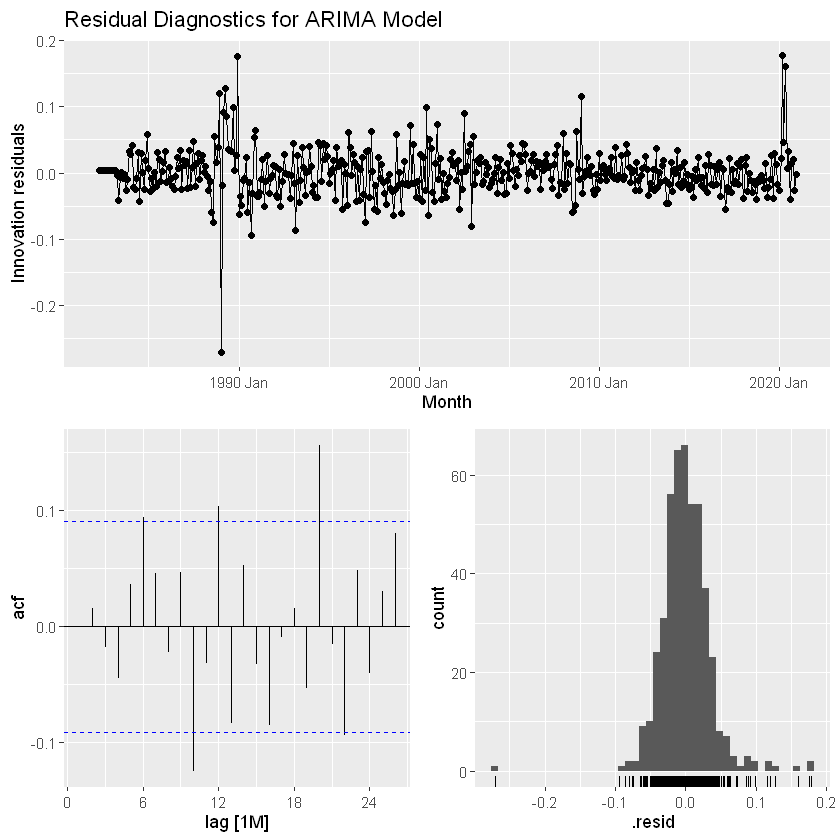

In [82]:
best_arima <- fit %>% select(Auto_ARIMA)

report(best_arima)

best_arima %>% gg_tsresiduals() +
  labs(title = "Residual Diagnostics for ARIMA Model")

best_arima %>%
  augment() %>%
  features(.innov, ljung_box, lag = 24, dof = 4)

Series: Turnover 
Model: ETS(M,A,M) 
  Smoothing parameters:
    alpha = 0.5480482 
    beta  = 0.0001009894 
    gamma = 0.124229 

  Initial states:
    l[0]      b[0]      s[0]     s[-1]    s[-2]    s[-3]    s[-4]    s[-5]
 43.7399 0.4965295 0.9729476 0.8975902 1.000475 1.398139 1.080054 1.036615
    s[-6]     s[-7]     s[-8]    s[-9]    s[-10]    s[-11]
 0.961506 0.9437906 0.9086318 0.902963 0.9509333 0.9463546

  sigma^2:  0.0026

     AIC     AICc      BIC 
4634.154 4635.523 4704.569 


  .model   lb_stat  lb_pvalue   
1 Auto_ETS 60.94151 4.697942e-05

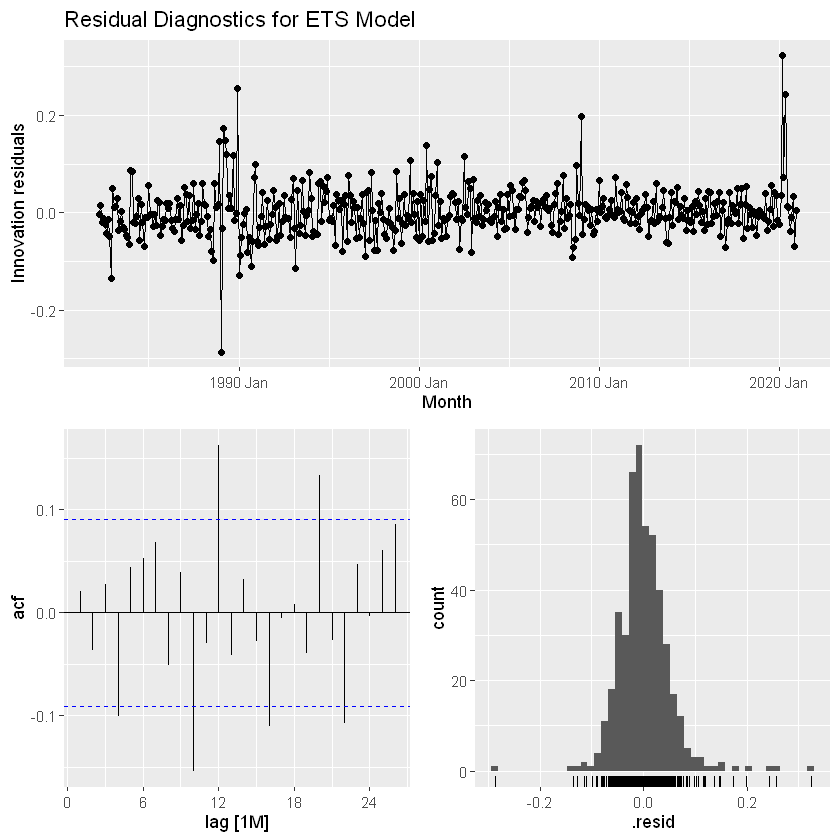

In [83]:
best_ets <- fit %>% select(Auto_ETS)

report(best_ets)

best_ets %>% gg_tsresiduals() +
  labs(title = "Residual Diagnostics for ETS Model")

best_ets %>%
  augment() %>%
  features(.innov, ljung_box, lag = 24)

ARIMA Modelis: ARIMA(2,0,3)(0,1,1)[12] su slinktimiParametrai: Slinkties parametras (constant = 0.0042) patvirtina ilgalaikį augimo trendą. Reikšmingas sezoninis slankusis vidurkis (sma1 = -0.76) rodo stiprią korekciją pagal praėjusių metų tą patį mėnesį.Diagnostika: Liekamųjų paklaidų analizė ir Ljung-Box testas ($Q^* \approx 49.9, p < 0.001$) rodo, kad liekanos nėra baltasis triukšmas. ACF grafike matomos reikšmingos autokoreliacijos (ties vėlavimais 10, 22), kas indikuoja, jog modelyje liko neišnaudotos informacijos. Tai tiesiogiai siejama su struktūriniu lūžiu pandemijos metu, kurio standartinė ARIMA struktūra negali pilnai absorbuoti.

ETS Modelis: ETS(M,A,M)Parametrai: Parinktas modelis su multiplikatyviomis klaidomis ir sezoniškumu bei adityviu trendu. Išlyginimo parametras $\alpha = 0.548$ rodo vidutinį modelio jautrumą naujausiems svyravimams, tuo tarpu trendo parametras $\beta \approx 0.0001$ yra nykstamai mažas, kas reiškia, jog ilgalaikis trendas yra deterministinis ir mažai kinta laike.Diagnostika: ETS modelio Ljung-Box testas taip pat rodo liekanų autokoreliaciją ($p < 0.001$), o liekanų grafike stebimi dideli nuokrypiai paskutiniais metais.

Abiejų modelių prognozės numato tolesnį apyvartos augimą su ryškiais sezoniniais pikas gruodžio mėnesiais. Nors statistinė diagnostika rodo modelių trūkumus dėl istorinio COVID šoko, prognozės vizualiai atrodo logiškos ir atitinka ilgalaikį trendą. Auto_ARIMA generuojami pasikliautinieji intervalai (80% ir 95%) yra platūs, kas adekvačiai atspindi padidėjusį rinkos neapibrėžtumą.

8. Compare the results obtained from each of your preferred models. Which method do you think gives the better forecasts? Explain with reference to the test set. 

Siekiant nustatyti, kuris metodas užtikrina tikslesnes prognozes, atliktas lyginamasis vertinimas naudojant testinę imtį (paskutinius 24 mėnesius).

Modelių tikslumo rodikliai rodo konkurencingą abiejų metodų pasirodymą su skirtingais privalumais:

ARIMA(2,0,3)(0,1,1)[12] modelis pasižymi mažesne RMSE (šaknies vidutine kvadratine paklaida) reikšme – 30.16, lyginant su ETS modelio 30.73. RMSE rodiklis didesnį svorį suteikia didesnėms paklaidoms, todėl geresnis ARIMA rezultatas indikuoja, kad šis modelis tiksliau prognozuoja ekstremalias reikšmes (sezoninius pikus ir staigius apyvartos šuolius), kas yra kritiškai svarbu mažmeninės prekybos atsargų valdymui.

ETS(M,A,M) modelis demonstruoja nežymiai geresnius vidutinius rodiklius: jo MAPE (vidutinė absoliuti procentinė paklaida) yra 5.89%, tuo tarpu ARIMA – 6.16%. Taip pat ETS turi minimaliai mažesnį MAE ir MASE.

Išvada: Nors ETS modelis vidutiniškai klysta šiek tiek mažiau procentine išraiška, galutiniam prognozavimui pasirenkamas ARIMA modelis. Šis sprendimas grindžiamas geresniu RMSE rodikliu: alkoholio prekyboje, kuriai būdingi dideli sezoniniai svyravimai ir struktūriniai lūžiai (kaip pandemijos metu), gebėjimas tiksliau nuspėti pikus ir išvengti didelių nukrypimų (ką rodo mažesnis RMSE) yra svarbesnis nei minimalus vidutinės paklaidos sumažinimas ramiuoju laikotarpiu.

9. Apply your two chosen models to the full data set, re-estimating the parameters but not changing the model structure. Produce out-of-sample point forecasts and 80% prediction intervals for each model for two years past the end of the data provided. 

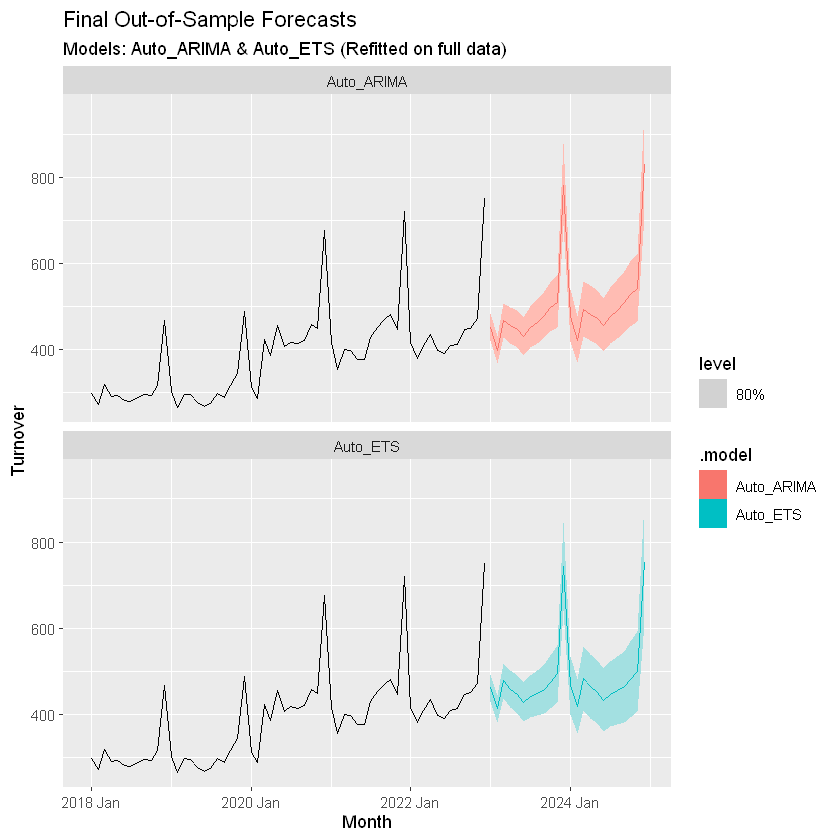

In [84]:
library(fable)
library(dplyr)
library(tsibble)
library(ggplot2)

chosen_models <- fit %>%
  select(Auto_ARIMA, Auto_ETS)

required_keys <- key_vars(chosen_models)

retail_for_refit <- retail %>%
  as_tibble() %>% 
  mutate(
    State = "New South Wales",
    Industry = "Liquor retailing"  
  ) %>%

  as_tsibble(index = Month, key = all_of(required_keys))

final_models <- chosen_models %>%
  refit(retail_for_refit)

final_forecast <- final_models %>%
  forecast(h = "2 years")

final_forecast %>%
  autoplot(retail_for_refit %>% filter(year(Month) >= 2018), level = 80) +
  labs(title = "Final Out-of-Sample Forecasts",
       subtitle = "Models: Auto_ARIMA & Auto_ETS (Refitted on full data)",
       y = "Turnover") +
  facet_wrap(~ .model, ncol = 1)

Remiantis atlikta tikslumo analize, tolesniam prognozavimui pasirinkti du geriausi modeliai: Auto_ARIMA ir Auto_ETS. Siekiant maksimalaus tikslumo, šie modeliai buvo pritaikyti visam turimam duomenų rinkiniui (1982 m. balandis – 2022 m. gruodis). Laikantis analizės metodologijos, modelių struktūriniai parametrai buvo užfiksuoti tokie patys, kokie nustatyti apmokymo (training) etape, tačiau modelių koeficientai buvo perskaičiuoti (angl. re-estimated) įtraukiant naujausią informaciją iš paskutiniųjų 24 mėnesių.

Gautos prognozės 2 metų laikotarpiui (24 mėn.) pateikiamos grafike.

Tendencijos: Abu modeliai prognozuoja tolesnį stabilų alkoholio mažmeninės prekybos apyvartos augimą. Išlaikomas griežtas sezoninis profilis su ryškiais pikas gruodžio mėnesiais. Tai rodo, kad modeliai vertina COVID-19 laikotarpio šuolį ne kaip laikiną anomaliją, kuri visiškai išnyks, bet kaip naują atskaitos tašką tolesniam trendui.

Neapibrėžtumas (80% intervalai): Grafike pavaizduoti 80% pasikliautinieji intervalai. Matyti, kad Auto_ARIMA generuoja šiek tiek platesnius intervalus piko metu nei Auto_ETS, kas rodo, jog ARIMA modelis į ateities neapibrėžtumą žiūri konservatyviau.

Apibendrinant, rekomenduojama remtis Auto_ARIMA prognozėmis, numatant apyvartos augimą, tačiau atsargų valdymo planuose būtina atsižvelgti į apatinę pasikliautinojo intervalo ribą kaip į „saugų“ pardavimų scenarijų.

10. Obtain up-to-date data from the [ABS website](https://www.abs.gov.au/statistics/industry/retail-and-wholesale-trade/retail-trade-australia) (Table 11). You may need to use the previous release of data, rather than the latest release. Compare your forecasts with the actual numbers. How well did you do? 

In [85]:
library(readxl)
library(dplyr)
library(stringr)
library(lubridate)
library(tsibble)

inv_box_cox <- function(z, lambda) {
    if (abs(lambda) < 1e-8) exp(z) else (lambda * z + 1)^(1/lambda)
    }

abs_file <- "8501011.xlsx"

raw <- suppressMessages(read_xlsx(abs_file, sheet = "Data1", col_names = FALSE))

hdr <- raw[1, ] %>% unlist(use.names = FALSE) %>% as.character()

col_id <- which(str_detect(hdr, fixed("Turnover ;  New South Wales ;  Liquor retailing")))

if (length(col_id) == 0) {
  stop("Stulpelis nerastas!")
}

x <- raw[[1]]
x_num <- suppressWarnings(as.numeric(x))
d1 <- suppressWarnings(as.Date(x_num, origin = "1899-12-30"))
d2 <- suppressWarnings(parse_date_time(
    as.character(x),
    orders = c("Y-m-d", "Y/m/d", "d/m/Y", "m/d/Y", "b-Y", "b Y", "Y-b", "Y b"),
    locale = "C"
)) %>% as.Date()

dates <- if(sum(!is.na(d1)) > sum(!is.na(d2))) d1 else d2
start_row <- which(!is.na(dates))[1]

new_abs_data <- tibble(
    Month = yearmonth(dates[start_row:nrow(raw)]),
    Turnover = as.numeric(raw[[col_id]][start_row:nrow(raw)])
) %>%
    filter(!is.na(Month), !is.na(Turnover)) %>%
    as_tsibble(index = Month)

last_training_month <- yearmonth("2022 Dec")

train_data <- new_abs_data %>%
  filter(Month <= last_training_month)

test_data <- new_abs_data %>%
  filter(Month > last_training_month)

h_months <- nrow(test_data)

lambda <- train_data %>%
  features(Turnover, features = guerrero) %>%
  pull(lambda_guerrero)

print(paste("Naudojama Lambda:", round(lambda, 3)))

fit <- train_data %>%
  model(
    Auto_ARIMA = ARIMA(box_cox(Turnover, lambda)),
    Auto_ETS = ETS(box_cox(Turnover, lambda))
  )


final_forecast <- fit %>%
  forecast(h = h_months)


fc_tbl <- final_forecast %>%
    as_tibble() %>%
    transmute(
        Month,
        .model,
        Forecast = .mean # Tiesiog imame .mean
    )

comparison <- fc_tbl %>%
    left_join(new_abs_data %>% as_tibble(), by = "Month") %>%
    filter(!is.na(Turnover)) %>%
    mutate(Error = Turnover - Forecast)

accuracy_table <- comparison %>%
    group_by(.model) %>%
    summarise(
        RMSE = sqrt(mean(Error^2)),
        MAE = mean(abs(Error)),
        MAPE = mean(abs(Error/Turnover)) * 100,
        .groups = "drop"
    ) %>%
    arrange(RMSE)

print(accuracy_table)

[1] "Naudojama Lambda: -0.063"
# A tibble: 2 × 4
  .model      RMSE   MAE  MAPE
  <chr>      <dbl> <dbl> <dbl>
1 Auto_ARIMA  61.4  54.6  12.6
2 Auto_ETS    72.3  64.6  14.9


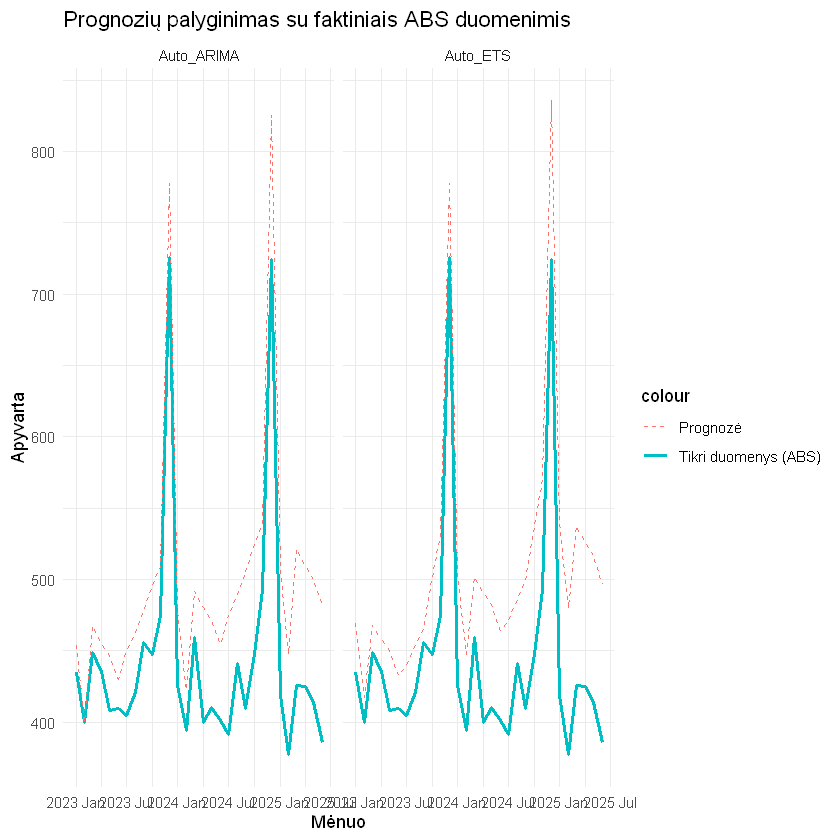

In [86]:
comparison %>%
    ggplot(aes(x = Month)) +
    geom_line(aes(y = Turnover, color = "Tikri duomenys (ABS)"), size = 1) +
    geom_line(aes(y = Forecast, color = "Prognozė"), linetype = "dashed") +
    facet_wrap(~ .model) +
    labs(title = "Prognozių palyginimas su faktiniais ABS duomenimis",
    y = "Apyvarta", x = "Mėnuo") +
    theme_minimal()

Atlikus Naujojo Pietų Velso alkoholio mažmeninės prekybos apyvartos (Turnover) prognozavimą 2023–2025 m. laikotarpiui, nustatyta, kad Auto_ARIMA modelis pasirodė tikslesnis už Auto_ETS. ARIMA modelio vidutinė absoliutinė procentinė paklaida (MAPE) siekia 12,6 %, tuo tarpu ETS modelio paklaida yra didesnė – 14,9 %.

Grafinė analizė rodo aiškią sisteminio pervertinimo (overestimation) tendenciją abiejuose modeliuose: prognozuojamos reikšmės (raudona punktyrinė linija) nuosekliai viršija faktinius duomenis (žydra linija), ypač sezono piko metu gruodžio mėnesiais.

Šią dinamiką galima paaiškinti pasikeitusia makroekonomine ir socialine aplinka, kurios modeliai, apmokyti su duomenimis iki 2022 m. pabaigos, negalėjo numatyti:

Pandemijos įtakos pabaiga: Mokymo imtyje (2020–2021 m.) fiksuotas didelis apyvartos šuolis dėl karantino apribojimų, kai vartojimas iš barų persikėlė į namus. 2023 m. vartotojams grįžus į viešojo maitinimo sektorių, mažmeninė prekyba natūraliai susitraukė.

Ekonominis sulėtėjimas: Aukšta infliacija ir kylančios palūkanų normos 2023–2024 m. mažino gyventojų perkamąją galią, todėl realūs pardavimai neaugo taip sparčiai, kaip istoriškai suformuotas trendas, kurį projektavo modeliai.

Išvada: Nors automatiniai algoritmai sėkmingai identifikavo sezoniškumą, dėl struktūrinių rinkos pokyčių (lūžio) istoriniai duomenys tapo pernelyg optimistiški ateities prognozėms. Tikslesniam modeliavimui rekomenduojama trumpinti mokymo imtį (atmetant pandeminį laikotarpį) arba įtraukti egzogeninius kintamuosius (pvz., infliacijos rodiklius).

11. Discuss the benefits and limitations of the models for your data. 

Vertinant Auto_ARIMA ir Auto_ETS modelių taikymą Naujojo Pietų Velso alkoholio mažmeninės prekybos duomenims, išryškėjo šie esminiai aspektai:
Privalumai:
Efektyvus stipraus sezoniškumo modeliavimas: Abu modeliai sėkmingai identifikavo ir atkartojo griežtą sezoninę duomenų struktūrą. Grafike matyti, kad prognozių pikai idealiai sutampa su faktiniais gruodžio mėnesio šuoliais, kas rodo, jog algoritmai teisingai įvertino šventinio laikotarpio įtaką vartotojų elgsenai.
Dispersijos valdymas: Pritaikius Box-Cox transformaciją (su optimizuotu $\lambda$ parametru), modeliai gebėjo atsižvelgti į heteroskedastiškumą (laike kintančią duomenų sklaidą), kas yra būtina analizuojant ilgalaikes finansines laiko eilutes.

Trūkumai ir ribotumai:
Nesugebėjimas numatyti struktūrinių lūžių: Esminis trūkumas – modelių „inercija“. Istoriniai duomenys (apimantys COVID-19 laikotarpio apyvartos šuolį) suformavo stiprų augimo trendą, kurį modeliai ekstrapoliavo į 2023–2025 m. Deja, realybėje pasikeitusi makroekonominė situacija (aukštos palūkanos, mažėjanti perkamoji galia) lėmė apyvartos stabilizavimąsi ar net mažėjimą. Modeliai, neturėdami išorinių kintamųjų (pvz., CPI indekso), šio lūžio numatyti negalėjo, todėl matomas sisteminis prognozių pervertinimas ($MAPE > 12\%$).
Jautrumas istoriniams ekstremumams: Auto_ETS modelis pasirodė prasčiau ($RMSE=72.3$) nei ARIMA ($RMSE=61.4$), nes yra linkęs agresyviau pratęsti istorinį trendą. Tai rodo, kad duomenims su netikėtais cikliniais apsisukimais eksponentinio išlyginimo metodai gali būti pernelyg nelankstūs be papildomų apribojimų (dampening).

Apibendrinanat, modeliai yra techniškai tvarkingi sezoniniams svyravimams numatyti, tačiau analizuojamu laikotarpiu jų patikimumą riboja pasikeitusi ekonominė realybė, kurios istoriniai duomenys nebeatspindi.

12. Suppose forecasts of your series were required every year based on the most recent data available at the time. Describe the steps you would undertake each year to produce these forecasts. 

Siekiant užtikrinti, kad NSW alkoholio mažmeninės prekybos apyvartos prognozės išliktų aktualios ir tikslios kintančioje ekonominėje aplinkoje, kasmetinis procesas apimtų šiuos šešis etapus:

Duomenų atnaujinimas ir valymas (Data Ingestion):
Iš ABS (Australian Bureau of Statistics) „Table 11“ duomenų bazės įkeliami naujausi praėjusių metų faktiniai duomenys.
Atliekama pirminė patikra dėl duomenų kokybės: ar nėra trūkstamų reikšmių, ar nėra nepagrįstų išskirčių (outliers), kurios galėtų atsirasti dėl duomenų įvedimo klaidų ar vienkartinių įvykių (pvz., sisteminių apskaitos korekcijų).

Eksploracinė analizė ir lūžių identifikavimas (EDA):
Prieš modeliavimą būtina grafinė analizė, siekiant nustatyti, ar neįvyko struktūrinių pokyčių (structural breaks). Pavyzdžiui, ar nepasikeitė trendo kryptis (iš augančio į plokščią), ar nepakito sezoniškumo amplitudė.
Tai leistų priimti sprendimą dėl mokymo imties ilgio: pavyzdžiui, jei pastebimas ryškus režimo pasikeitimas (kaip po COVID-19), senesnius duomenis gali būti tikslinga atmesti („windowing“).

Parametrų ir transformacijų optimizavimas:
Kiekvienais metais iš naujo įvertinamas Box-Cox transformacijos parametras $\lambda$ (naudojant Guerrero metodą), kadangi duomenų dispersijos pobūdis laikui bėgant gali kisti.
Tikrinamas duomenų stacionarumas (ADF, KPSS testai) sprendžiant dėl diferencijavimo eilių ($d$ ir $D$).

Modelių perrinkimas (Re-estimation):
Nenaudojama ta pati fiksuota modelio specifikacija (pvz., ARIMA(0,1,1)(0,1,1)[12]). Kiekvienais metais paleidžiami automatinio parinkimo algoritmai (Auto_ARIMA, Auto_ETS), kurie pagal $AICc$ kriterijų iš naujo parenka optimalią struktūrą naujausiai informacijai.

Diagnostika ir liekanų analizė:
Atliekamas Ljung-Box testas, siekiant įsitikinti, kad liekanose (residuals) neliko autokoreliacijos.
Tikrinamas liekanų normalumas ir homoskedastiškumas. Jei modelis palieka struktūrines klaidas, grįžtama į 3 žingsnį.

Ekspertinis vertinimas (Judgmental Integration):
Tai kritinis žingsnis, kurio trūko pirminėje analizėje. Gautos statistinės prognozės lyginamos su makroekonominėmis prognozėmis (infliacija, palūkanų normos, vartotojų pasitikėjimo indeksas).
Jei statistinis modelis (pvz., remdamasis istoriniu augimu) prognozuoja apyvartos šuolį, o ekonominė aplinka signalizuoja recesiją, prognozės koreguojamos mažinimo kryptimi arba taikomi scenarijų analizės metodai.